<a href="https://colab.research.google.com/github/r2x4/hackathon/blob/main/hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  

----
# <center><font color="#615FFF" size="8"> Hackathon Oracle </font></center>
----

#  

----
# <center><font color="#615FFF" size="6"> Carga Datos </font></center>
----

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
data = pd.read_excel("/content/data.xlsx")

In [30]:
data.shape

(7043, 21)

In [31]:
data.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3556,0895-LNKRC,Male,0,Yes,Yes,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.45,113.50,No
4859,8041-TMEID,Male,1,Yes,No,63,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Credit card (automatic),108.50,6991.90,No
2957,2674-MIAHT,Female,0,No,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,80.30,324.20,No
848,9778-OGKQZ,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),92.00,6782.15,No
5162,4801-KFYKL,Male,0,No,Yes,8,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),19.45,159.20,No


In [32]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [33]:
data.rename(columns={
    'customerID': 'id_cliente',
    'gender': 'genero',
    'SeniorCitizen': 'adulto_mayor',
    'Partner': 'tiene_pareja',
    'Dependents': 'tiene_dependientes',
    'tenure': 'antiguedad_meses',
    'PhoneService': 'servicio_telefono',
    'MultipleLines': 'lineas_multiples',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_en_linea',
    'OnlineBackup': 'respaldo_en_linea',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_peliculas',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'facturacion_electronica',
    'PaymentMethod': 'metodo_pago',
    'MonthlyCharges': 'cargo_mensual',
    'TotalCharges': 'cargos_totales',
    'Churn': 'abandono_cliente'
}, inplace=True)


In [34]:
data.sample(5)

,id_cliente,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,servicio_internet,seguridad_en_linea,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,facturacion_electronica,metodo_pago,cargo_mensual,cargos_totales,abandono_cliente
2945,3987-KQDDU,Male,0,No,No,9,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Electronic check,75.60,661.55,No
3105,4429-WYGFR,Male,0,No,No,26,Yes,No,DSL,No,...,No,Yes,No,No,Month-to-month,No,Bank transfer (automatic),49.15,1237.30,No
1167,4189-NAKJS,Male,0,No,No,26,Yes,Yes,DSL,No,...,No,No,No,No,One year,Yes,Credit card (automatic),51.55,1295.40,No
2117,4139-DETXS,Female,0,Yes,Yes,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),64.45,4528.00,No
2886,3170-GWYKC,Female,0,No,No,60,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),104.95,6236.75,No


In [35]:
# memoria de datos

round(data.memory_usage(deep=True).sum() / 1024**2, 3)

np.float64(6.506)

In [36]:
data.isnull().sum()

,0
id_cliente,0
genero,0
adulto_mayor,0
tiene_pareja,0
tiene_dependientes,0
antiguedad_meses,0
servicio_telefono,0
lineas_multiples,0
servicio_internet,0
seguridad_en_linea,0


#  

----
# <center><font color="#615FFF" size="6"> Analisis Univariado </font></center>
----

In [37]:
cat_cols = data.select_dtypes(include="object").columns
num_cols = data.select_dtypes(exclude="object").columns

In [38]:
data[num_cols].describe()

,adulto_mayor,antiguedad_meses,cargo_mensual,cargos_totales
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


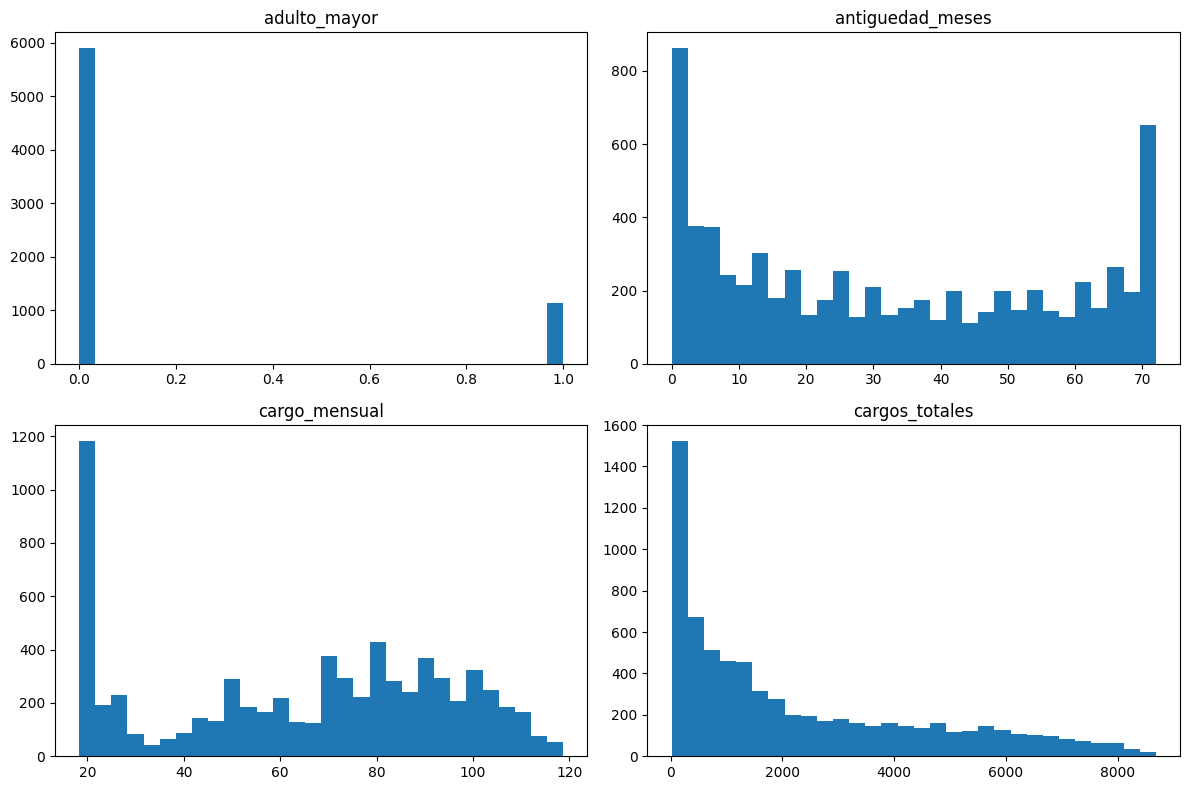

In [39]:
import math

n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(data[col], bins=30)
    axes[i].set_title(col)

# Eliminar ejes vacíos
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


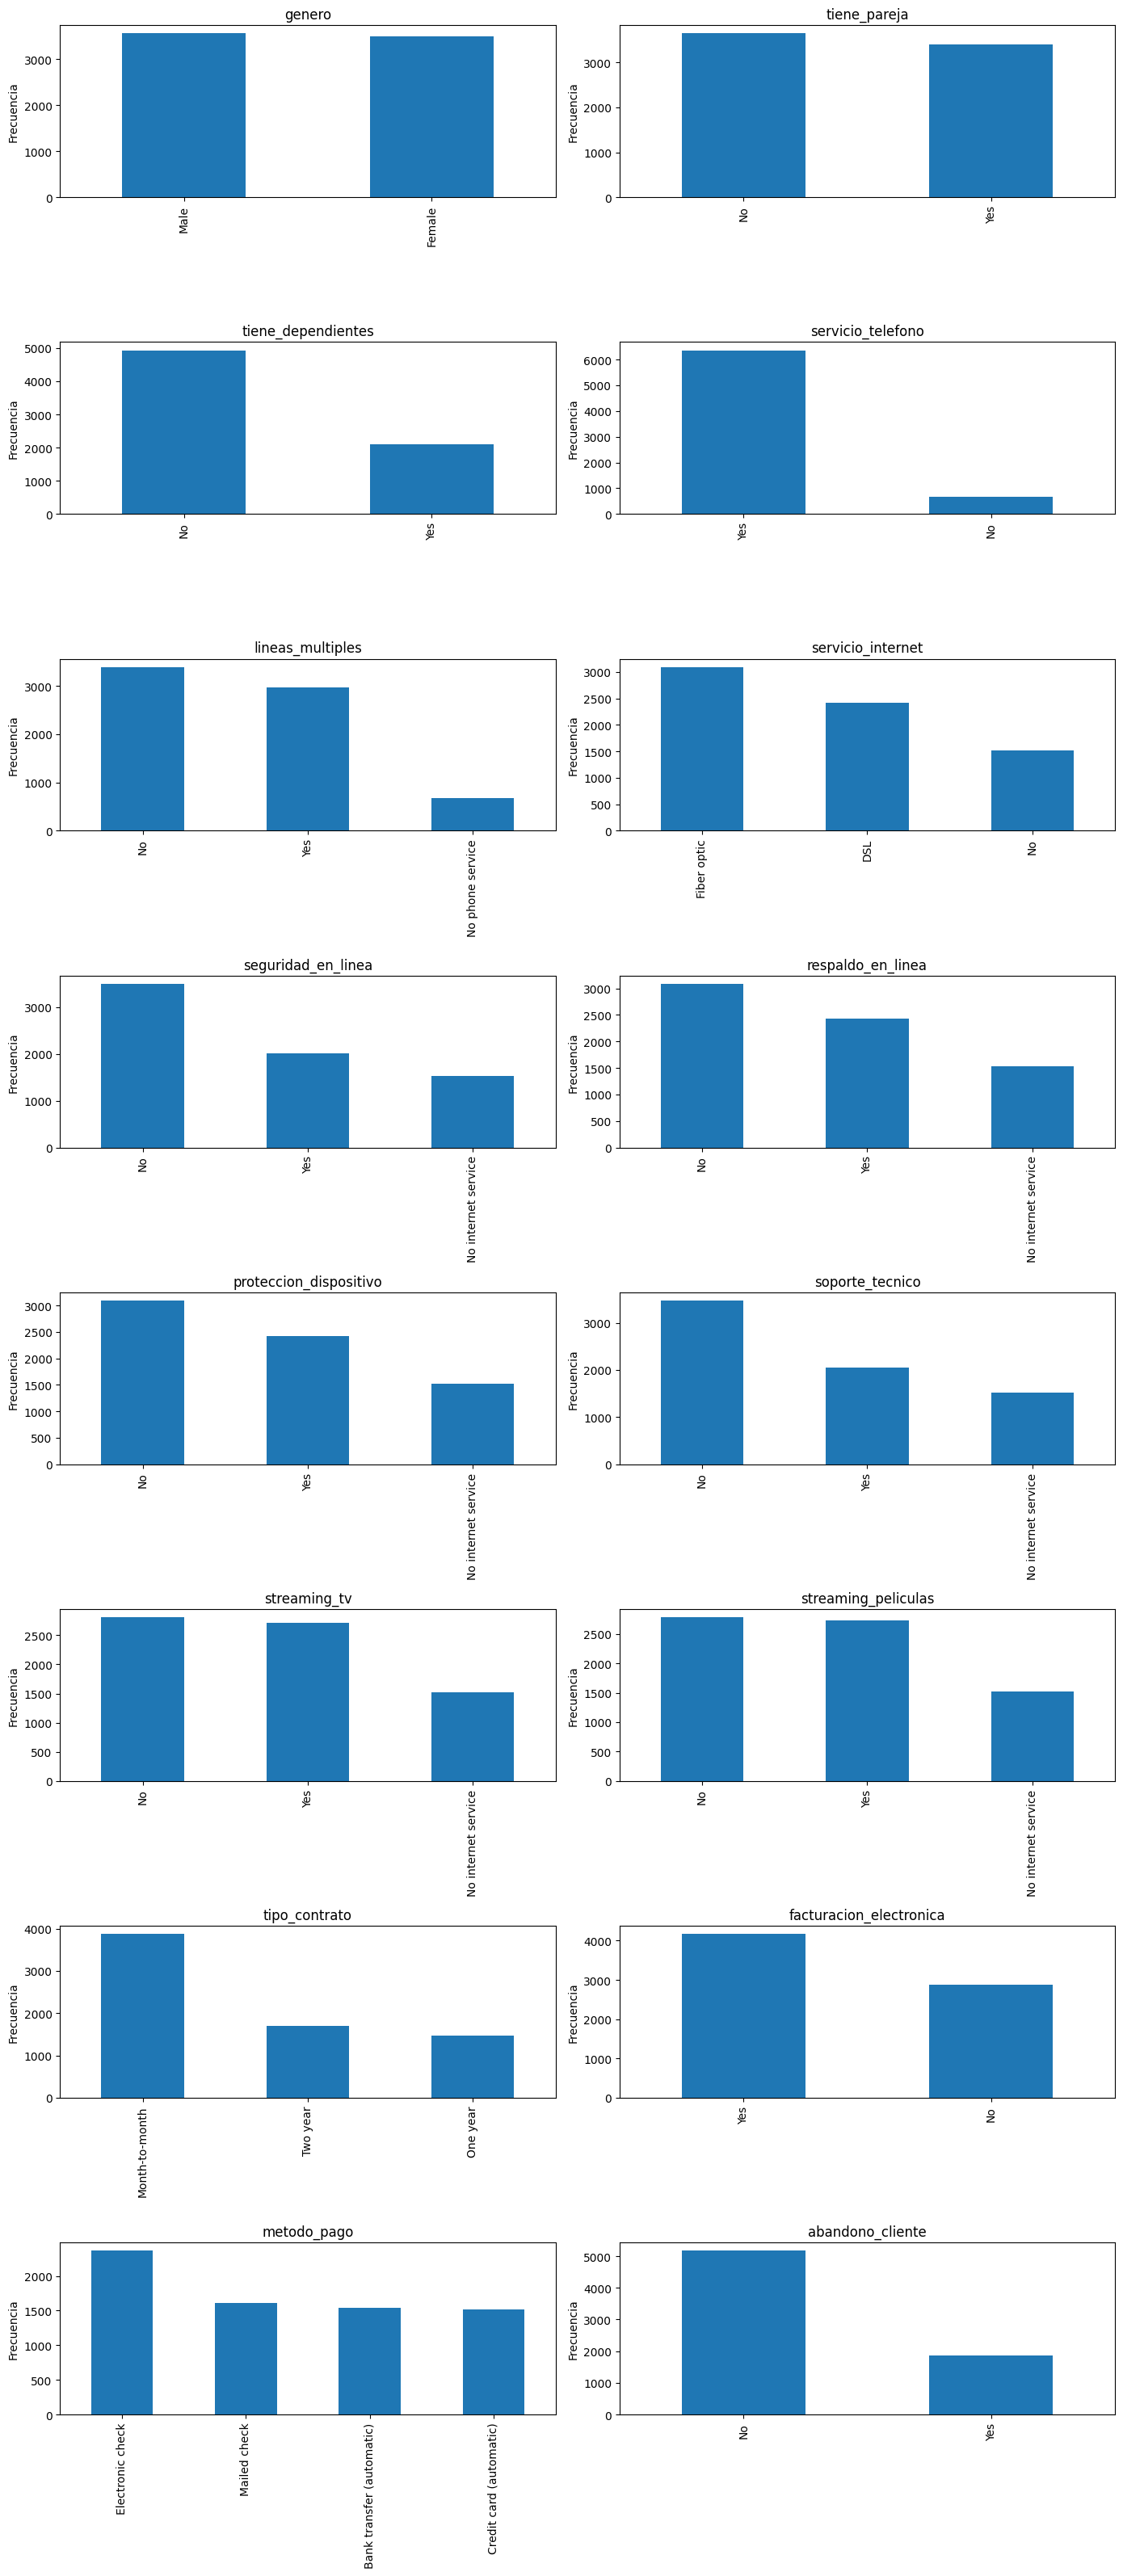

In [42]:
# se exclulle id_cliente muchas aristas o vistas

import math

# Excluir columna
cat_cols_plot = [col for col in cat_cols if col != 'id_cliente']

n_cols = 2
n_rows = math.ceil(len(cat_cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    data[col].value_counts().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

# Eliminar ejes vacíos
for j in range(len(cat_cols_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()